# Sensitivity Analysis: Stem+Leaf Storage Hydraulics

This notebook runs multiple simulations using `HalophyteStemLeafStorageMultiComp` (hydraulics) and `C3_c_leaf_reduc` (photosynthesis).

The initial setup includes 3 scenarios with varied:
- `pi0_stem`
- `pi0_leaf`
- `VWT` (stem storage volume)
- `GWMAX` mode (`manual` or `equation`)

`GWMAX` equation option uses the same form as in the `Pecan` species class:

`GWMAX = CAP * VWT * 10**6 / (0.63 * 4 * 60 * 60)`

In [ ]:
%load_ext autoreload
%autoreload 2
%aimport hydraulics
%aimport species_traits

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

from species_traits import *
from soil import SoilMultiple, SaltySoilMultiple, Loam, Sand, DrydownSoil, ConstantSoil
from defs import SimulationMultiComp, Atmosphere, steps
from photosynthesis import C3, C3_c_leaf_reduc
import hydraulics

# Global plot typography for report figures
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Caladea", "STIX Two Text", "Constantia", "Georgia", "Cambria"],
    "font.size": 12,
})

print("Libraries imported successfully")

Libraries imported successfully


## Configuration

In [ ]:
# Core simulation configuration
duration = 40
timestepM = 30
dt = timestepM * 60.0
#weatherFile = r"sample_data\AgadirInterp30.xlsx"
weatherFile = r"sample_data\Lab_Weather_Joined_Interp30.xlsx"

# Multi-compartment soil configuration
num_compartments = 2
zr_arr = np.array([1.0, 1.0])
s_init_arr = np.array([0.25, 0.25])
cs_init_arr = np.array([50.0, 50.0])
root_frac_arr = np.array([0.5, 0.5])
B_param = 10000

# ---------------------------------------------------------------------------
# Optional post-burn switch block (easy to comment out for baseline behavior)
# ---------------------------------------------------------------------------
enable_post_burn_cs_reset = True
post_burn_cs_arr = np.array([150.0, 150.0])
post_burn_soil_dynamics = "constant"        # "constant" or "drydown"

# Shared legend title and red report palette
legend_title = "Starting filtration efficiency (-)"
scenario_palette = ["#fcbba1", "#fb6a4a", "#99000d"]

# Storage initial conditions
vwi_stem = 0.85
vwi_leaf = 0.90
c_stem = 5.0
c_leaf = None

# Shared stem/leaf PV parameters (except pi0 values which vary by scenario)
wr_stem = 0.40 # Average stem apoplastic fraction for species in Xu, 2023
wft_stem = 1.0
eta_stem = 5.8 # Average value for maximum bulk mod. of elast. from Cao, 2019
mcap_stem = 12

wr_leaf = 0.46 # Reported by Rieger and Daniell for Pecan leaves
wft_leaf = 1.0
eta_leaf = 17.5 # Maximum bulk mod. of elast. from Andersen and Brodbeck, 1988
mcap_leaf = 12

# Uptake test configuration
salt_uptake = True
leaf_uptake_frac = 0.5

# Height of stem/root storage compartment
f_cap = 0.5

# Storage psi_w mode for both stem and leaf
psi_wf_mode = "bartlett"

# Helper to compute GWMAX from VWT and CAP (same equation used in Pecan class)
def gwmax_from_equation(vwt, cap):
    return cap * vwt * 10**6 / (0.63 * 4 * 60 * 60)

# gwmax_mode: 'equation' or 'manual'
# gcut: either 'species' (use species default GCUT) or a numeric value
# This run varies only starting filtration efficiency while keeping other settings fixed.
scenario_configs = [
    {
        "name": "S1",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": True,
        "dynamic_E": False,
        "E": 0.80,
    },
    {
        "name": "S2",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": True,
        "dynamic_E": False,
        "E": 0.95,
    },
    {
        "name": "S3",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": True,
        "dynamic_E": False,
        "E": 0.98,
    },
]

print(f"Duration: {duration} days | Timestep: {timestepM} minutes")
print(f"Compartments: {num_compartments}, root fractions: {root_frac_arr}")
print(f"Configured scenarios: {len(scenario_configs)}")
print(f"default salt_uptake={salt_uptake}, leaf_uptake_frac={leaf_uptake_frac}")
print("Scenario uptake flags:", {cfg['name']: cfg.get('salt_uptake', salt_uptake) for cfg in scenario_configs})
print("Scenario E values:", {cfg['name']: cfg.get('E', 0.99) for cfg in scenario_configs})
print("Scenario dynamic_E:", {cfg['name']: cfg.get('dynamic_E', False) for cfg in scenario_configs})
print(f"Post-burn cs reset enabled={enable_post_burn_cs_reset}, post_burn_soil_dynamics={post_burn_soil_dynamics}")

Duration: 40 days | Timestep: 30 minutes
Compartments: 2, root fractions: [0.5 0.5]
Configured scenarios: 3
default salt_uptake=True, leaf_uptake_frac=0.5
Scenario uptake flags: {'S1': True, 'S2': True, 'S3': True}
Scenario E values: {'S1': 0.8, 'S2': 0.95, 'S3': 0.98}
Scenario dynamic_E: {'S1': False, 'S2': False, 'S3': False}
Post-burn cs reset enabled=True, post_burn_soil_dynamics=constant


In [ ]:
# Load weather data and linearly resample to match timestepM

df = pd.read_excel(weatherFile, engine="openpyxl")

# Required forcing columns in weather files

required_cols = ["Temperature", "Relative Humidity", "GHI"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:

    raise KeyError(f"Weather file missing required columns: {missing_cols}")



# Infer source timestep from a datetime column when available; otherwise assume 30 min source data.

source_timestepM = 30.0

for dt_col in ["DateTime", "Datetime", "datetime", "Timestamp", "timestamp", "Time"]:

    if dt_col in df.columns:

        t = pd.to_datetime(df[dt_col], errors="coerce")

        t = t.dropna()

        if len(t) > 1:

            delta_min = np.diff(t.values).astype("timedelta64[s]").astype(float) / 60.0

            delta_min = delta_min[np.isfinite(delta_min) & (delta_min > 0)]

            if len(delta_min) > 0:

                source_timestepM = float(np.median(delta_min))

        break



src_n = len(df)

src_minutes = np.arange(src_n, dtype=float) * source_timestepM



# Target timeline keeps the same total weather duration but at requested model timestep.

timestepM_float = float(timestepM)

target_n = int(np.floor(src_minutes[-1] / timestepM_float)) + 1

target_minutes = np.arange(target_n, dtype=float) * timestepM_float



def resample_linear(series):

    y = np.asarray(series, dtype=float)

    return np.interp(target_minutes, src_minutes, y)



tempC = resample_linear(df["Temperature"].values)

rh = resample_linear(df["Relative Humidity"].values)

phiInp = list(resample_linear(df["GHI"].values))



taInp = list(tempC + 273.0)



A_SAT = 611.2

B_SAT = 17.67

C_SAT = 243.5

P_ATM = 101325

psat = A_SAT * np.exp((B_SAT * tempC) / (C_SAT + tempC))

qaInp = list(0.622 * (rh / 100.0) * psat / P_ATM)



print(f"Weather loaded: {src_n} source steps at ~{source_timestepM:g} min")

print(f"Weather resampled: {len(taInp)} steps at {timestepM} min")

Weather loaded: 17521 source steps at ~30 min
Weather resampled: 17521 steps at 30 min


## Build Scenario Models

In [ ]:
def build_scenario_model(cfg):
    species_obj = Pecan()

    # Override VWT for this scenario
    species_obj.VWT = cfg["VWT"]

    # Set GWMAX from either manual value or equation
    gw_mode = str(cfg.get("gwmax_mode", "equation")).strip().lower()
    if gw_mode == "manual":
        if cfg.get("GWMAX_manual") is None:
            raise ValueError(f"Scenario {cfg['name']} uses manual GWMAX but GWMAX_manual is None")
        species_obj.GWMAX = float(cfg["GWMAX_manual"])
    elif gw_mode == "equation":
        species_obj.GWMAX = gwmax_from_equation(species_obj.VWT, species_obj.CAP)
    else:
        raise ValueError(f"Unknown gwmax_mode for scenario {cfg['name']}: {gw_mode}")

    # Simple GCUT control: use species value or a manual numeric value
    gcut_setting = cfg.get("gcut", "species")
    if isinstance(gcut_setting, str) and gcut_setting.strip().lower() == "species":
        scenario_gcut = float(species_obj.GCUT)
    else:
        scenario_gcut = float(gcut_setting)

    scenario_salt_uptake = bool(cfg.get("salt_uptake", salt_uptake))
    scenario_E = float(cfg.get("E", 0.99))
    scenario_dynamic_E = bool(cfg.get("dynamic_E", False))
    scenario_c_stem_max = cfg.get("c_stem_max", None)

    total_steps = steps(duration, int(timestepM))
    if cfg.get("burn_in_days") is not None:
        burn_in_steps = steps(float(cfg["burn_in_days"]), int(timestepM))
    else:
        burn_in_steps = int(cfg.get("burn_in_steps", 0))
    burn_in_steps = max(0, min(burn_in_steps, total_steps))

    atmosphere_obj = Atmosphere(phiInp[0], taInp[0], qaInp[0])
    soil_obj = SaltySoilMultiple(
        stype=Sand(),
        # stype=Loam(),
        dynamics=DrydownSoil(),
        zr=zr_arr,
        s=s_init_arr,
        cs=cs_init_arr,
    )
    photo_obj = C3_c_leaf_reduc(
    # photo_obj = C3(
        species_obj,
        atmosphere_obj,
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf,
    )

    hydro_obj = hydraulics.HalophyteStemLeafStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=c_stem,
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=cfg["pi0_stem"],
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        dt=dt,
        salt_uptake=scenario_salt_uptake,
        psi_wf_mode=psi_wf_mode,
        vwi_leaf=vwi_leaf,
        c_leaf=c_leaf,
        wr_leaf=wr_leaf,
        wft_leaf=wft_leaf,
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf,
        mcap_leaf=mcap_leaf,
        leaf_uptake_frac=leaf_uptake_frac,
        gcut=scenario_gcut,
        E=scenario_E,
        F_CAP=f_cap,
        dynamic_E=scenario_dynamic_E,
        c_stem_max=scenario_c_stem_max,
    )

    plant_obj = SimulationMultiComp(
        species_cls=species_obj,
        atm_cls=atmosphere_obj,
        soil_cls=soil_obj,
        photo_cls=photo_obj,
        hydro_cls=hydro_obj,
        zr_arr=zr_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        dt=dt,
    )

    label = rf"$E_{{start}} = {scenario_E:.2f}$"

    return {
        "config": cfg,
        "label": label,
        "species": species_obj,
        "plant": plant_obj,
        "hydro": hydro_obj,
        "burn_in_steps": burn_in_steps,
    }

scenario_runs = [build_scenario_model(cfg) for cfg in scenario_configs]

for run in scenario_runs:
    print(run["label"])


$E_{start} = 0.80$
$E_{start} = 0.95$
$E_{start} = 0.98$


## Run Simulations

In [95]:
# Set hydro references on photosynthesis objects for c_leaf access
for run in scenario_runs:
    run['plant'].photo.hydro_ref = run['plant'].hydro

print(f"Running {len(scenario_runs)} scenarios for {duration} days...")
n_steps = steps(duration, int(timestepM))
progress_stride = max(1, n_steps // 4)

results_by_scenario = {}
for run in scenario_runs:
    scenario_name = run["config"]["name"]
    scenario_label = run["label"]
    plant_model = run["plant"]
    hydro_model = run["hydro"]
    burn_in_steps = int(run.get("burn_in_steps", 0))
    scenario_salt_uptake = bool(run["config"].get("salt_uptake", salt_uptake))

    # Optional per-scenario override for post-burn cs reset.
    scenario_post_burn_cs = np.array(run["config"].get("post_burn_cs", post_burn_cs_arr), dtype=float)

    print(f"\nStarting {scenario_name} (burn_in_steps={burn_in_steps})...")
    for i in range(n_steps):
        if i < burn_in_steps:
            # Burn-in: hold soil moisture fixed and use initial cs values.
            plant_model.soil.dynamics = [ConstantSoil() for _ in plant_model.soil.s]
            hydro_model.Salt_Uptake = False  # Always disable uptake during burn-in
        else:
            # Post-burn dynamics selector (easy to comment out/flip in config cell).
            if str(post_burn_soil_dynamics).strip().lower() == "constant":
                plant_model.soil.dynamics = [ConstantSoil() for _ in plant_model.soil.s]
            else:
                plant_model.soil.dynamics = [DrydownSoil() for _ in plant_model.soil.s]

            hydro_model.Salt_Uptake = scenario_salt_uptake  # Restore scenario setting after burn-in

            # One-time cs reset at the start of true simulation.
            if enable_post_burn_cs_reset and i == burn_in_steps:
                if len(scenario_post_burn_cs) != len(plant_model.soil.s):
                    raise ValueError(
                        f"Scenario {scenario_name}: post_burn_cs length {len(scenario_post_burn_cs)} "
                        f"does not match number of compartments {len(plant_model.soil.s)}"
                    )
                plant_model.soil.cs = scenario_post_burn_cs.copy()
                if hasattr(plant_model.soil, "MS"):
                    plant_model.soil.MS = plant_model.soil.cs * plant_model.soil.ZR * plant_model.soil.N * plant_model.soil.s
                print(f"  {scenario_name}: switched cs at start of true simulation to {plant_model.soil.cs}")

        plant_model.update(dt, phiInp[i], taInp[i], qaInp[i])
        if (i + 1) % progress_stride == 0 or i == 0 or i == n_steps - 1:
            print(f"  {scenario_name}: {i + 1}/{n_steps} timesteps ({(i + 1) / n_steps * 100:.1f}%)")

    results_by_scenario[scenario_name] = {
        "label": scenario_label,
        "burn_in_steps": burn_in_steps,
        "output": plant_model.output(),
    }
    print(f"Completed {scenario_name}")

print("\nAll scenario simulations complete.")

Running 3 scenarios for 40 days...

Starting S1 (burn_in_steps=480)...
  S1: 1/1920 timesteps (0.1%)
  S1: 480/1920 timesteps (25.0%)
  S1: switched cs at start of true simulation to [150. 150.]
  S1: 960/1920 timesteps (50.0%)
  S1: 1440/1920 timesteps (75.0%)
  S1: 1920/1920 timesteps (100.0%)
Completed S1

Starting S2 (burn_in_steps=480)...
  S2: 1/1920 timesteps (0.1%)
  S2: 480/1920 timesteps (25.0%)
  S2: switched cs at start of true simulation to [150. 150.]
  S2: 960/1920 timesteps (50.0%)
  S2: 1440/1920 timesteps (75.0%)
  S2: 1920/1920 timesteps (100.0%)
Completed S2

Starting S3 (burn_in_steps=480)...
  S3: 1/1920 timesteps (0.1%)
  S3: 480/1920 timesteps (25.0%)
  S3: switched cs at start of true simulation to [150. 150.]
  S3: 960/1920 timesteps (50.0%)
  S3: 1440/1920 timesteps (75.0%)
  S3: 1920/1920 timesteps (100.0%)
Completed S3

All scenario simulations complete.


## Run Output Setup

In [96]:
run_tag = datetime.now().strftime("%d%m%y_%H%M")
output_root = Path("output")
run_output_dir = output_root / run_tag
run_output_dir.mkdir(parents=True, exist_ok=True)

shared_config = {
    "duration": duration,
    "timestepM": timestepM,
    "dt": dt,
    "weatherFile": weatherFile,
    "num_compartments": num_compartments,
    "zr_arr": zr_arr.tolist(),
    "s_init_arr": s_init_arr.tolist(),
    "cs_init_arr": cs_init_arr.tolist(),
    "root_frac_arr": root_frac_arr.tolist(),
    "B_param": B_param,
    "vwi_stem": vwi_stem,
    "vwi_leaf": vwi_leaf,
    "c_stem": c_stem,
    "c_leaf": c_leaf,
    "wr_stem": wr_stem,
    "wft_stem": wft_stem,
    "eta_stem": eta_stem,
    "mcap_stem": mcap_stem,
    "wr_leaf": wr_leaf,
    "wft_leaf": wft_leaf,
    "eta_leaf": eta_leaf,
    "mcap_leaf": mcap_leaf,
    "psi_wf_mode": psi_wf_mode,
}

config_rows = []
for cfg in scenario_configs:
    row = dict(shared_config)
    row.update({f"scenario_{key}": value for key, value in cfg.items()})
    config_rows.append(row)

config_export_df = pd.DataFrame(config_rows)
config_csv_path = run_output_dir / "config_snapshot.csv"
config_export_df.to_csv(config_csv_path, index=False)

print(f"Run output directory: {run_output_dir.resolve()}")
print(f"Saved config snapshot: {config_csv_path.resolve()}")

Run output directory: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\070626_1043
Saved config snapshot: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\070626_1043\config_snapshot.csv


## Quick Summary Table

In [97]:
summary_rows = []
for cfg in scenario_configs:
    scenario_name = cfg["name"]
    out = results_by_scenario[scenario_name]["output"]
    ev = np.array(out["ev"])
    psi_l = np.array(out["psi_l"])
    psi_w_stem = np.array(out["psi_w_stem"])
    psi_w_leaf = np.array(out["psi_w_leaf"])

    summary_rows.append({
        "Scenario": scenario_name,
        "Label": results_by_scenario[scenario_name]["label"],
        "Integrated_ev_um": float(np.sum(ev)),
        "Mean_psi_l_MPa": float(np.mean(psi_l)),
        "Mean_psi_w_stem_MPa": float(np.mean(psi_w_stem)),
        "Mean_psi_w_leaf_MPa": float(np.mean(psi_w_leaf)),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Scenario,Label,Integrated_ev_um,Mean_psi_l_MPa,Mean_psi_w_stem_MPa,Mean_psi_w_leaf_MPa
0,S1,$E_{start} = 0.80$,57.171978,-1.234403,-1.011583,-1.235876
1,S2,$E_{start} = 0.95$,58.041397,-1.244264,-1.016653,-1.245723
2,S3,$E_{start} = 0.98$,58.050450,-1.244286,-1.016621,-1.245743


In [98]:
out = results_by_scenario['S1']["output"]['psi_s']
print(out)

[[np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-0.33688736217915893), np.float64(-

## Plot: Transpiration by Scenario

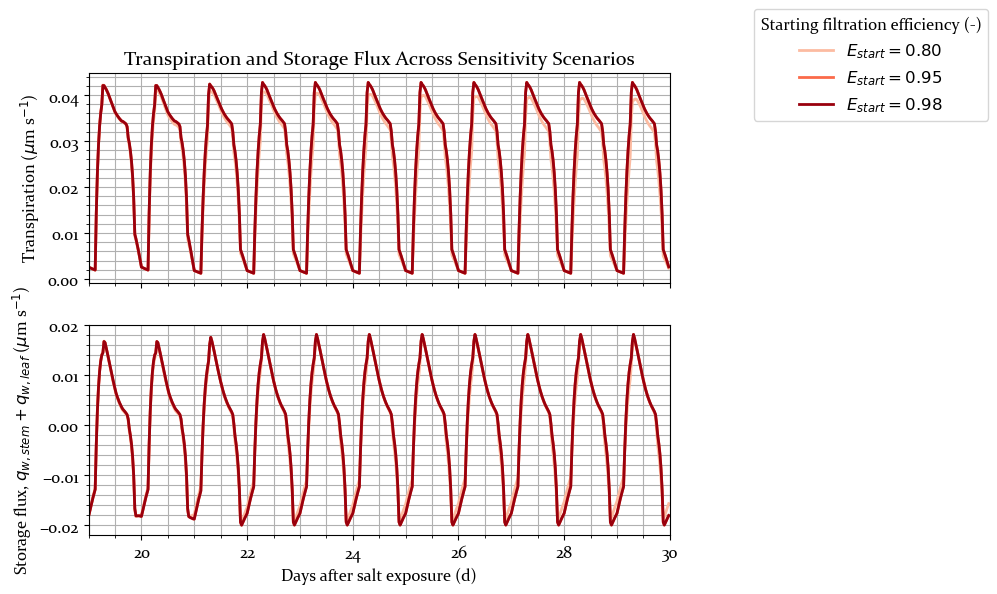

In [100]:
# Plot-window control: start immediately after burn-in by default
start_day_after_burn_in = 20

expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg['name']]["output"]
    candidate_lengths.extend([len(out["ev"]), len(out["qw_stem"]), len(out["qw_leaf"])])
n_plot = min(candidate_lengths)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
ax_top, ax_bottom = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    ev = np.array(out["ev"])[max_burn_in + plot_start_idx:n_plot]
    qw_stem = np.array(out["qw_stem"])[max_burn_in + plot_start_idx:n_plot]
    qw_leaf = np.array(out["qw_leaf"])[max_burn_in + plot_start_idx:n_plot]
    q_storage_sum = qw_stem + qw_leaf

    ax_top.plot(time_plot, ev, linewidth=2, color=color, label=label)
    ax_bottom.plot(time_plot, q_storage_sum, linewidth=2, color=color, label=label)

ax_top.set_title("Transpiration and Storage Flux Across Sensitivity Scenarios")
ax_top.set_ylabel(r"Transpiration ($\mu$m s$^{-1}$)")
ax_bottom.set_ylabel(r"Storage flux, $q_{w,stem}+q_{w,leaf}$ ($\mu$m s$^{-1}$)")
ax_bottom.set_xlabel("Days after salt exposure (d)")

xmax = post_burn_duration
xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_top.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.001, 1), loc="upper left")
# fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "transpiration_storage_flux.png", dpi=300, bbox_inches="tight")
plt.show()

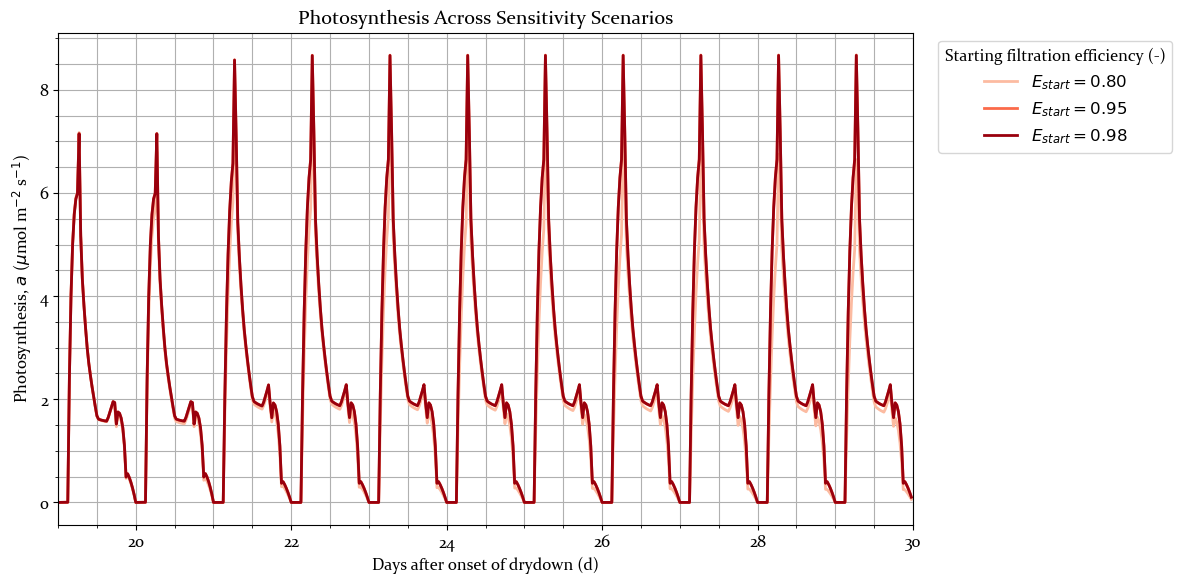

In [101]:
# Plot photosynthesis (a) for all scenarios on its own figure (post-burn-in only)
expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg['name']]["output"]
    candidate_lengths.append(len(out["a"]))
n_plot = min(candidate_lengths)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    a = np.array(out["a"])[max_burn_in + plot_start_idx:n_plot]
    ax.plot(time_plot, a, linewidth=2, color=scenario_colors[name], label=label)

ax.set_title("Photosynthesis Across Sensitivity Scenarios")
ax.set_xlabel("Days after onset of drydown (d)")
ax.set_ylabel(r"Photosynthesis, $a$ ($\mu$mol m$^{-2}$ s$^{-1}$)")
ax.set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
ax.minorticks_on()
ax.grid(visible=True, which="both", axis="both")
ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(run_output_dir / "photosynthesis.png", dpi=300, bbox_inches="tight")
plt.show()

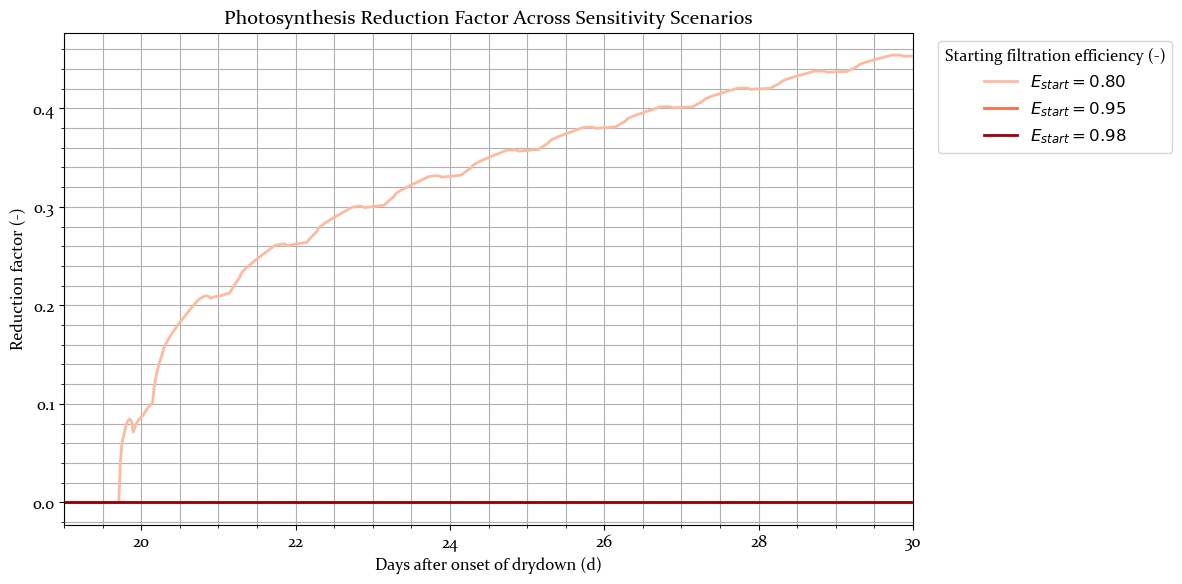

In [102]:
# Plot photosynthesis reduction factor (c_leaf_reduc or cs_reduc) on its own figure
expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
reduction_key_by_scenario = {}

for cfg in scenario_configs:
    name = cfg["name"]
    out = results_by_scenario[name]["output"]

    if "c_leaf_reduc" in out and len(out["c_leaf_reduc"]) > 0:
        reduction_key = "c_leaf_reduc"
    elif "cs_reduc" in out and len(out["cs_reduc"]) > 0:
        reduction_key = "cs_reduc"
    elif "photo_reduc" in out and len(out["photo_reduc"]) > 0:
        reduction_key = "photo_reduc"
    else:
        raise KeyError(f"No reduction-factor output found for scenario {name}.")

    reduction_key_by_scenario[name] = reduction_key
    candidate_lengths.append(len(out[reduction_key]))

n_plot = min(candidate_lengths)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    reduction_key = reduction_key_by_scenario[name]
    reduc = np.array(out[reduction_key])[max_burn_in + plot_start_idx:n_plot]
    ax.plot(time_plot, reduc, linewidth=2, color=scenario_colors[name], label=label)

ax.set_title("Photosynthesis Reduction Factor Across Sensitivity Scenarios")
ax.set_xlabel("Days after onset of drydown (d)")
ax.set_ylabel("Reduction factor (-)")
ax.set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
ax.minorticks_on()
ax.grid(visible=True, which="both", axis="both")
ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(run_output_dir / "photosynthesis_reduction_factor.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Potentials by Scenario

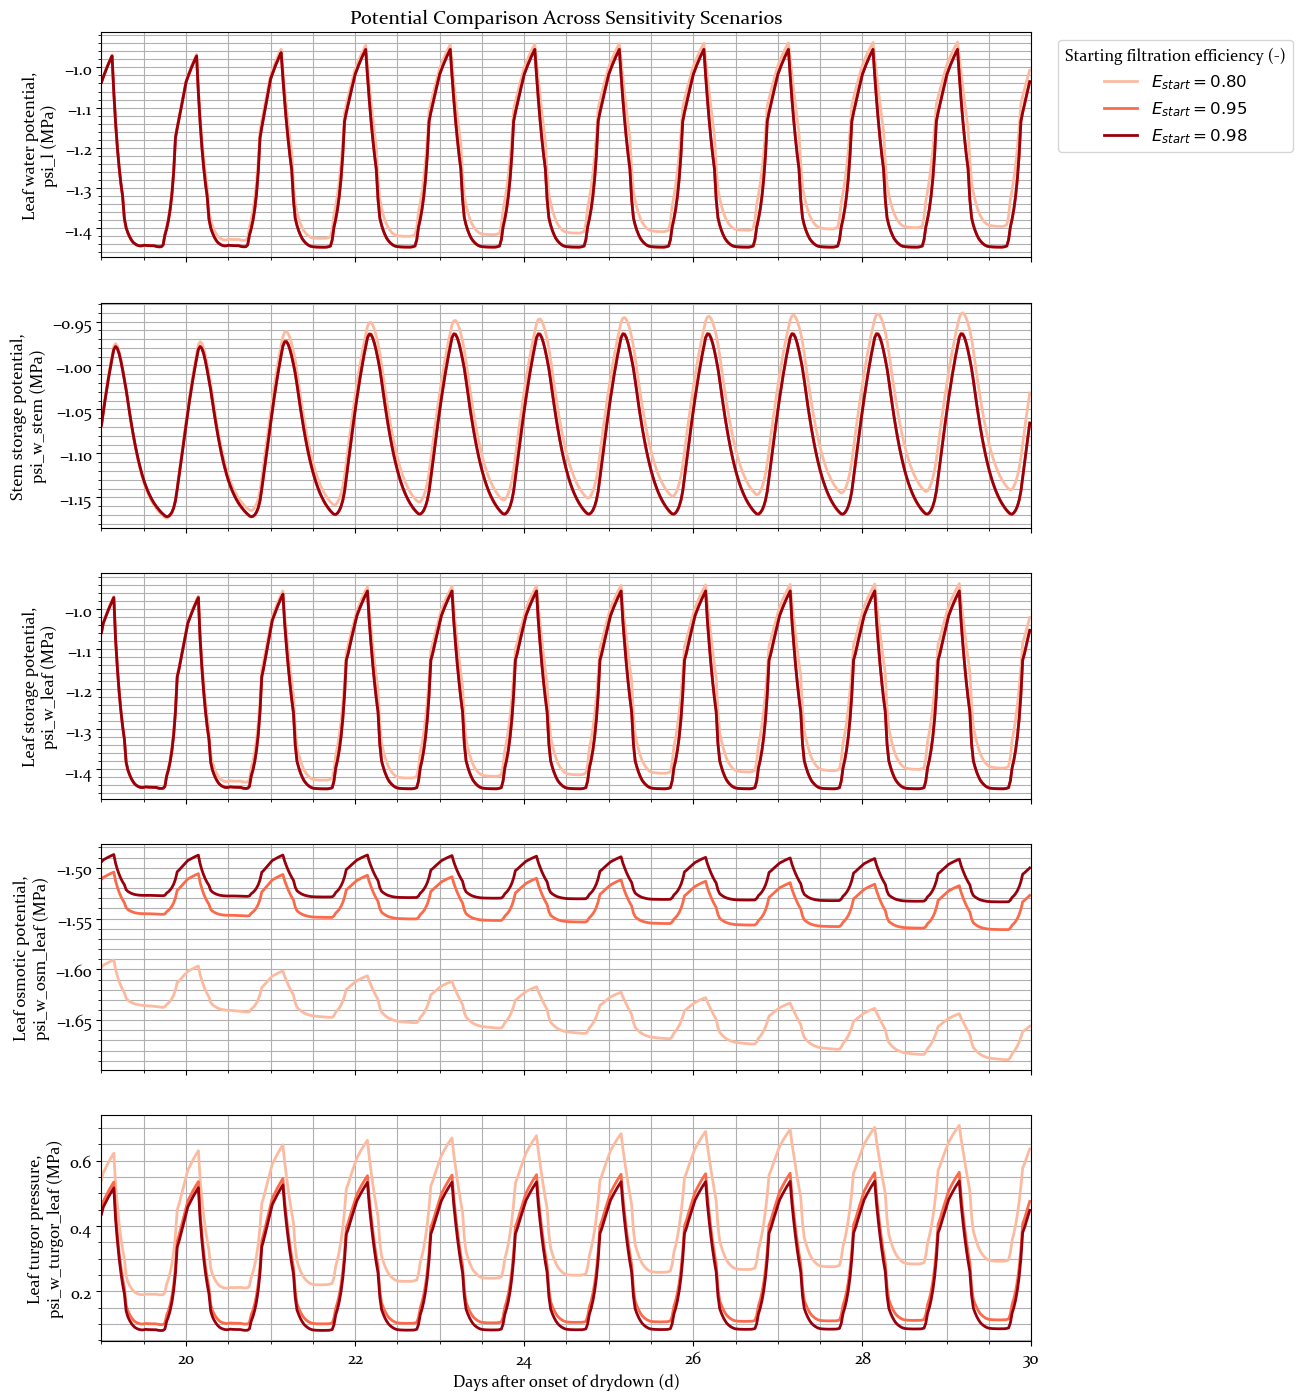

In [103]:
expected_steps = int(duration * 24 * 60 / timestepM)

candidate_lengths = []

for cfg in scenario_configs:

    out = results_by_scenario[cfg['name']]["output"]

    candidate_lengths.extend([

        len(out["psi_l"]),

        len(out["psi_w_stem"]),

        len(out["psi_w_leaf"]),

        len(out["psi_w_osm_leaf"]),

        len(out["psi_w_turgor_leaf"]),

    ])

n_plot = min(candidate_lengths)



# Use the maximum burn-in across scenarios so all series share the same time axis

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)

post_burn_steps = n_plot - max_burn_in

post_burn_duration = post_burn_steps * dt / 86400.0  # days



post_burn_days = np.arange(post_burn_steps) * dt / 86400.0

plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)

plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))

time_plot = post_burn_days[plot_start_idx:]



scenario_colors = {

    cfg["name"]: scenario_palette[i % len(scenario_palette)]

    for i, cfg in enumerate(scenario_configs)

}



series_specs = [

    ("psi_l", "Leaf water potential,\npsi_l (MPa)"),

    ("psi_w_stem", "Stem storage potential,\npsi_w_stem (MPa)"),

    ("psi_w_leaf", "Leaf storage potential,\npsi_w_leaf (MPa)"),

    ("psi_w_osm_leaf", "Leaf osmotic potential,\npsi_w_osm_leaf (MPa)"),

    ("psi_w_turgor_leaf", "Leaf turgor pressure,\npsi_w_turgor_leaf (MPa)"),

]



fig, axes = plt.subplots(len(series_specs), 1, figsize=(12, 17), sharex=True)



for ax, (key, ylabel) in zip(axes, series_specs):

    for cfg in scenario_configs:

        name = cfg["name"]

        label = results_by_scenario[name]["label"]

        y = np.array(results_by_scenario[name]["output"][key])[max_burn_in + plot_start_idx:n_plot]

        ax.plot(time_plot, y, linewidth=2, color=scenario_colors[name], label=label)

    ax.set_ylabel(ylabel)

    ax.minorticks_on()

    ax.grid(visible=True, which="both", axis="both")



axes[0].set_title("Potential Comparison Across Sensitivity Scenarios")

axes[-1].set_xlabel("Days after onset of drydown (d)")

axes[-1].set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)

axes[0].legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.savefig(run_output_dir / "potentials_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

## Plot: Soil Moisture Flux by Scenario


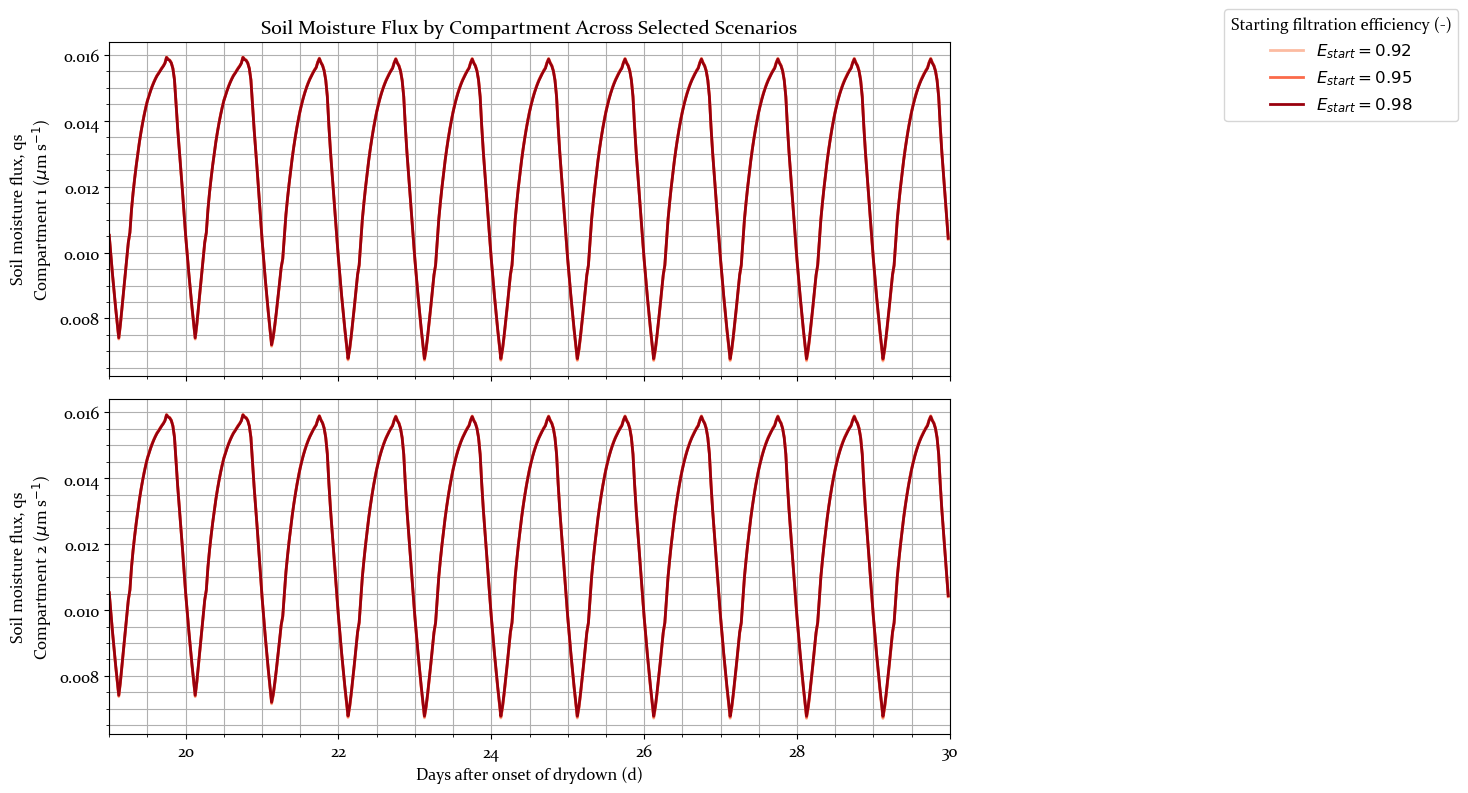

In [85]:
# Select which scenarios to plot (default = all)
scenarios_to_plot = [cfg["name"] for cfg in scenario_configs]
# To restrict, replace the line above with e.g.:
#   scenarios_to_plot = ["S1", "S3"]

candidate_lengths = []
for name in scenarios_to_plot:
    out = results_by_scenario[name]["output"]
    qs = out["qs"]
    for comp_series in qs:
        candidate_lengths.append(len(comp_series))
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

# One subplot per soil compartment
n_comps = len(results_by_scenario[scenarios_to_plot[0]]["output"]["qs"])
fig, axes = plt.subplots(n_comps, 1, figsize=(12, 4 * n_comps), sharex=True)
if n_comps == 1:
    axes = [axes]

scenario_colors = {
    name: scenario_palette[i % len(scenario_palette)]
    for i, name in enumerate(scenarios_to_plot)
}

for comp_idx, ax in enumerate(axes):
    for name in scenarios_to_plot:
        label = results_by_scenario[name]["label"]
        qs_comp = np.array(results_by_scenario[name]["output"]["qs"][comp_idx])[max_burn_in + plot_start_idx:n_plot]
        ax.plot(time_plot, qs_comp, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(f"Soil moisture flux, qs\nCompartment {comp_idx + 1} ($\\mu$m s$^{{-1}}$)")
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_title("Soil Moisture Flux by Compartment Across Selected Scenarios")
axes[-1].set_xlabel("Days after onset of drydown (d)")
axes[-1].set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "soil_moisture_flux.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stem and Leaf Water Content by Scenario

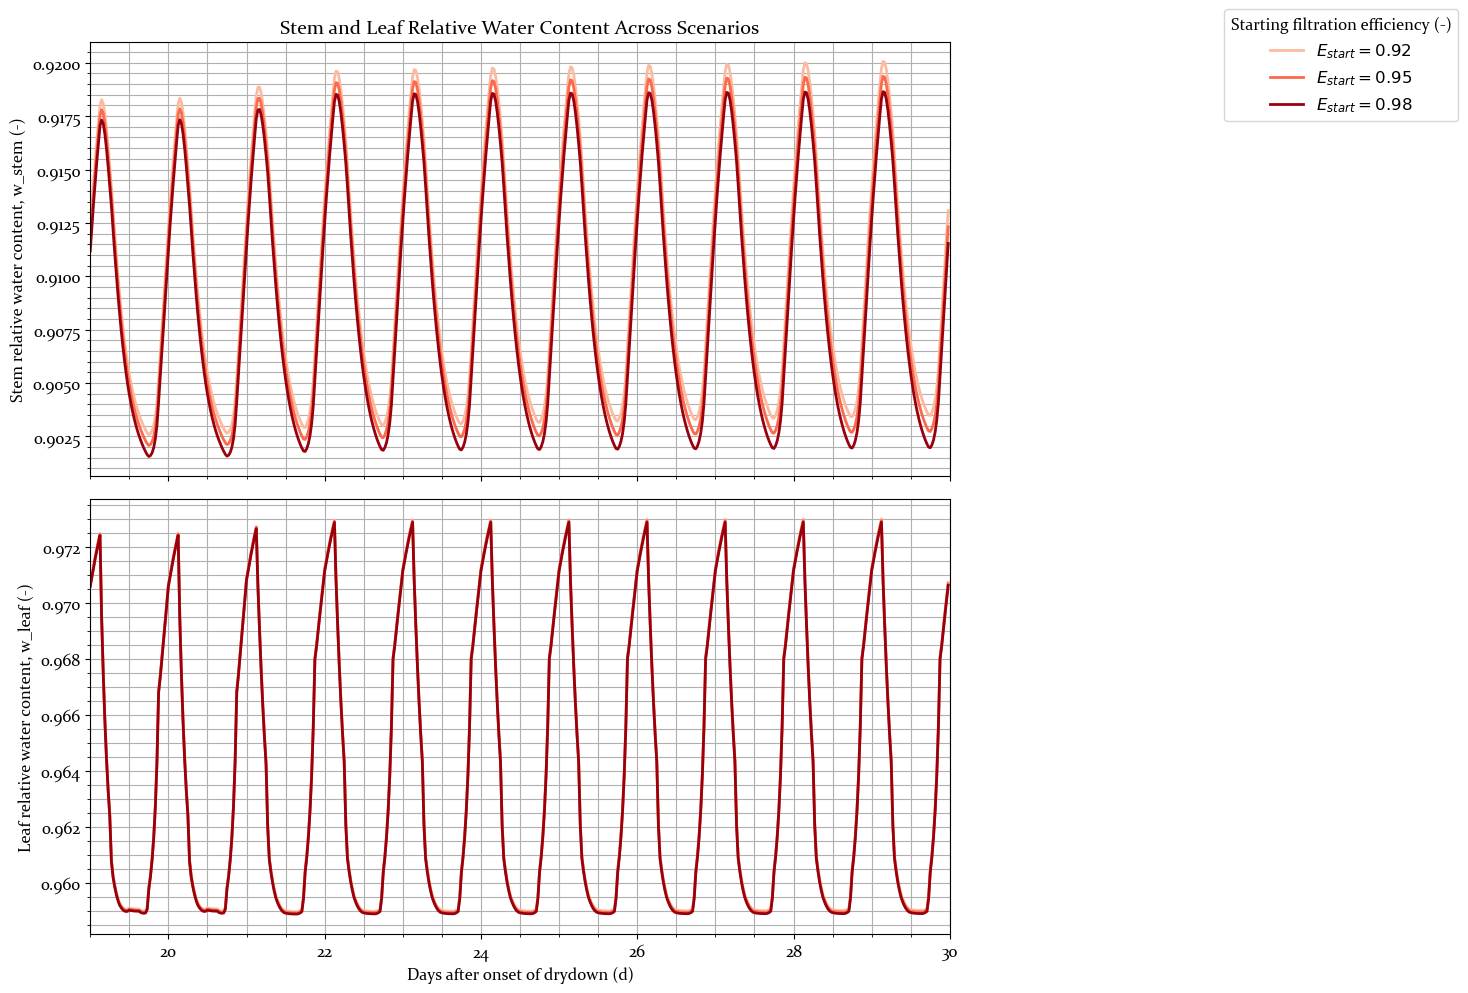

In [86]:
# Plot stem and leaf relative water content for all scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.extend([len(out["w_stem"]), len(out["w_leaf"])])
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax_stem, ax_leaf = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    w_stem = np.array(out["w_stem"])[max_burn_in + plot_start_idx:n_plot]
    w_leaf = np.array(out["w_leaf"])[max_burn_in + plot_start_idx:n_plot]

    ax_stem.plot(time_plot, w_stem, linewidth=2, color=color, label=label)
    ax_leaf.plot(time_plot, w_leaf, linewidth=2, color=color, label=label)

ax_stem.set_title("Stem and Leaf Relative Water Content Across Scenarios")
ax_stem.set_ylabel("Stem relative water content, w_stem (-)")
ax_leaf.set_ylabel("Leaf relative water content, w_leaf (-)")
ax_leaf.set_xlabel("Days after onset of drydown (d)")

xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_stem.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "stem_leaf_water_content.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stomatal Conductance by Scenario

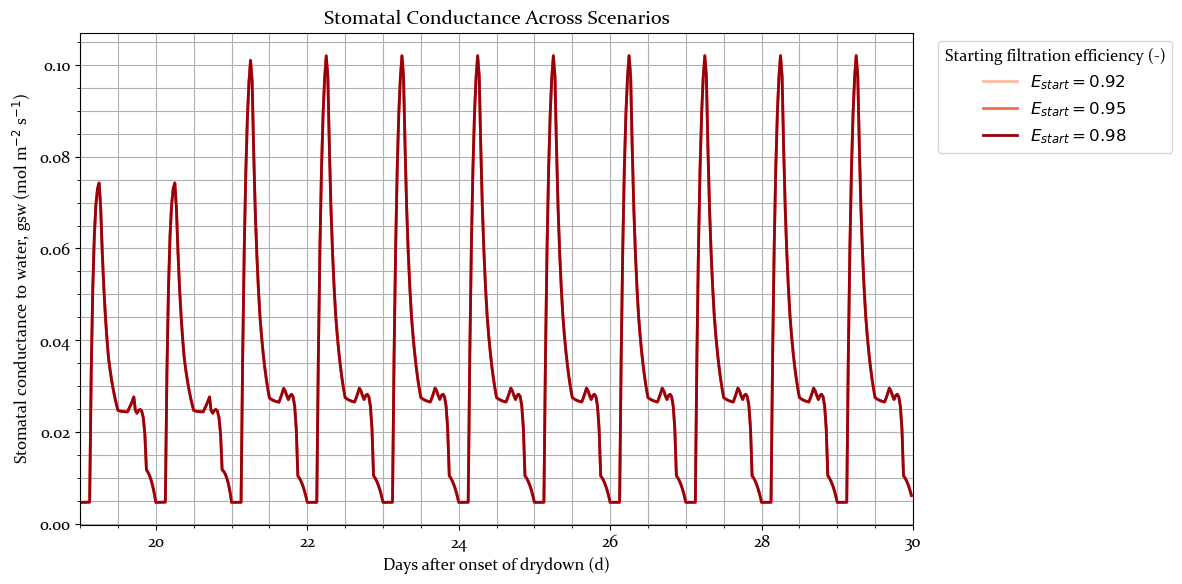

In [ ]:
# Plot stomatal conductance (gsw) for all scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.append(len(out["gsw"]))

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    gsw = np.array(out["gsw"])[max_burn_in + plot_start_idx:n_plot]
    ax.plot(time_plot, gsw, linewidth=2, color=scenario_colors[name], label=label)

ax.set_title("Stomatal Conductance Across Scenarios")
ax.set_xlabel("Day (d)")
ax.set_ylabel("Stomatal conductance to water, gsw (mol m$^{-2}$ s$^{-1}$)")
ax.set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
ax.minorticks_on()
ax.grid(visible=True, which="both", axis="both")
ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(run_output_dir / "stomatal_conductance.png", dpi=300, bbox_inches="tight")
plt.show()

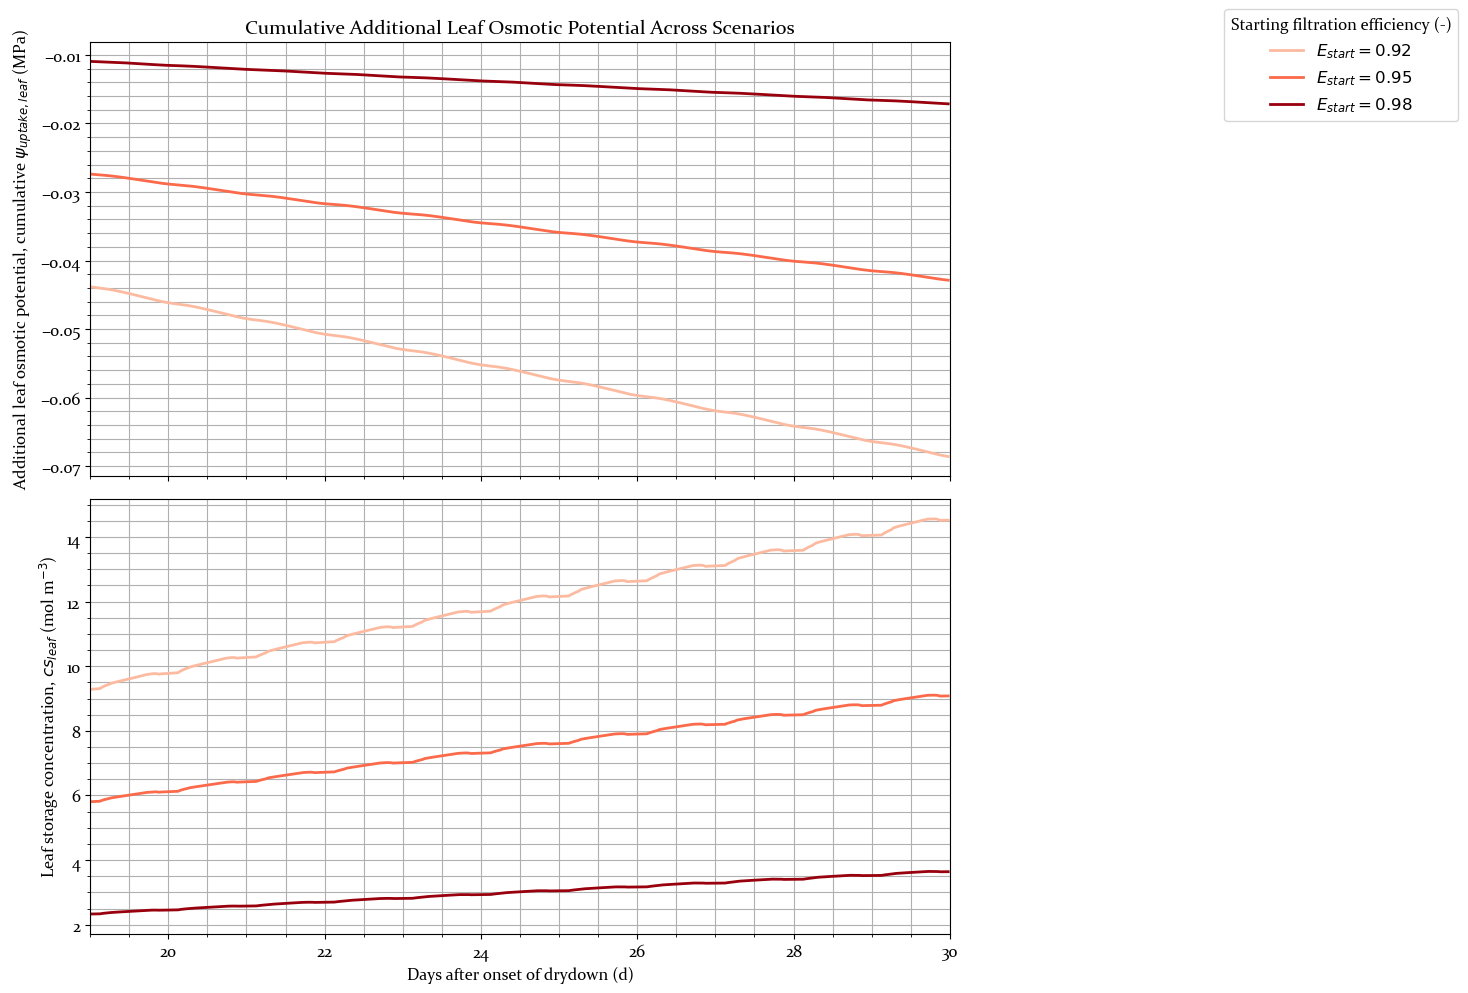

In [88]:
# Plot cumulative additional leaf osmotic potential and cs_leaf across scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    psi_leaf_series = out.get("psi_uptake_leaf_cum", out.get("psi_uptake_leaf", []))
    cs_leaf_series = out.get("c_leaf", [])
    candidate_lengths.extend([len(psi_leaf_series), len(cs_leaf_series)])

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax_top, ax_bottom = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]

    psi_uptake_leaf_cum = np.array(out.get("psi_uptake_leaf_cum", out["psi_uptake_leaf"]))[max_burn_in + plot_start_idx:n_plot]
    cs_leaf = np.array(out["c_leaf"])[max_burn_in + plot_start_idx:n_plot]

    ax_top.plot(
        time_plot,
        psi_uptake_leaf_cum,
        linewidth=2,
        color=scenario_colors[name],
        label=label,
    )
    ax_bottom.plot(
        time_plot,
        cs_leaf,
        linewidth=2,
        color=scenario_colors[name],
        label=label,
    )

ax_top.set_title("Cumulative Additional Leaf Osmotic Potential Across Scenarios")
ax_top.set_ylabel(r"Additional leaf osmotic potential, cumulative $\psi_{uptake,leaf}$ (MPa)")
ax_bottom.set_ylabel(r"Leaf storage concentration, $cs_{leaf}$ (mol m$^{-3}$)")
ax_bottom.set_xlabel("Days after onset of drydown (d)")

xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_top.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "leaf_osmotic_potential_and_cs_leaf.png", dpi=300, bbox_inches="tight")
plt.show()

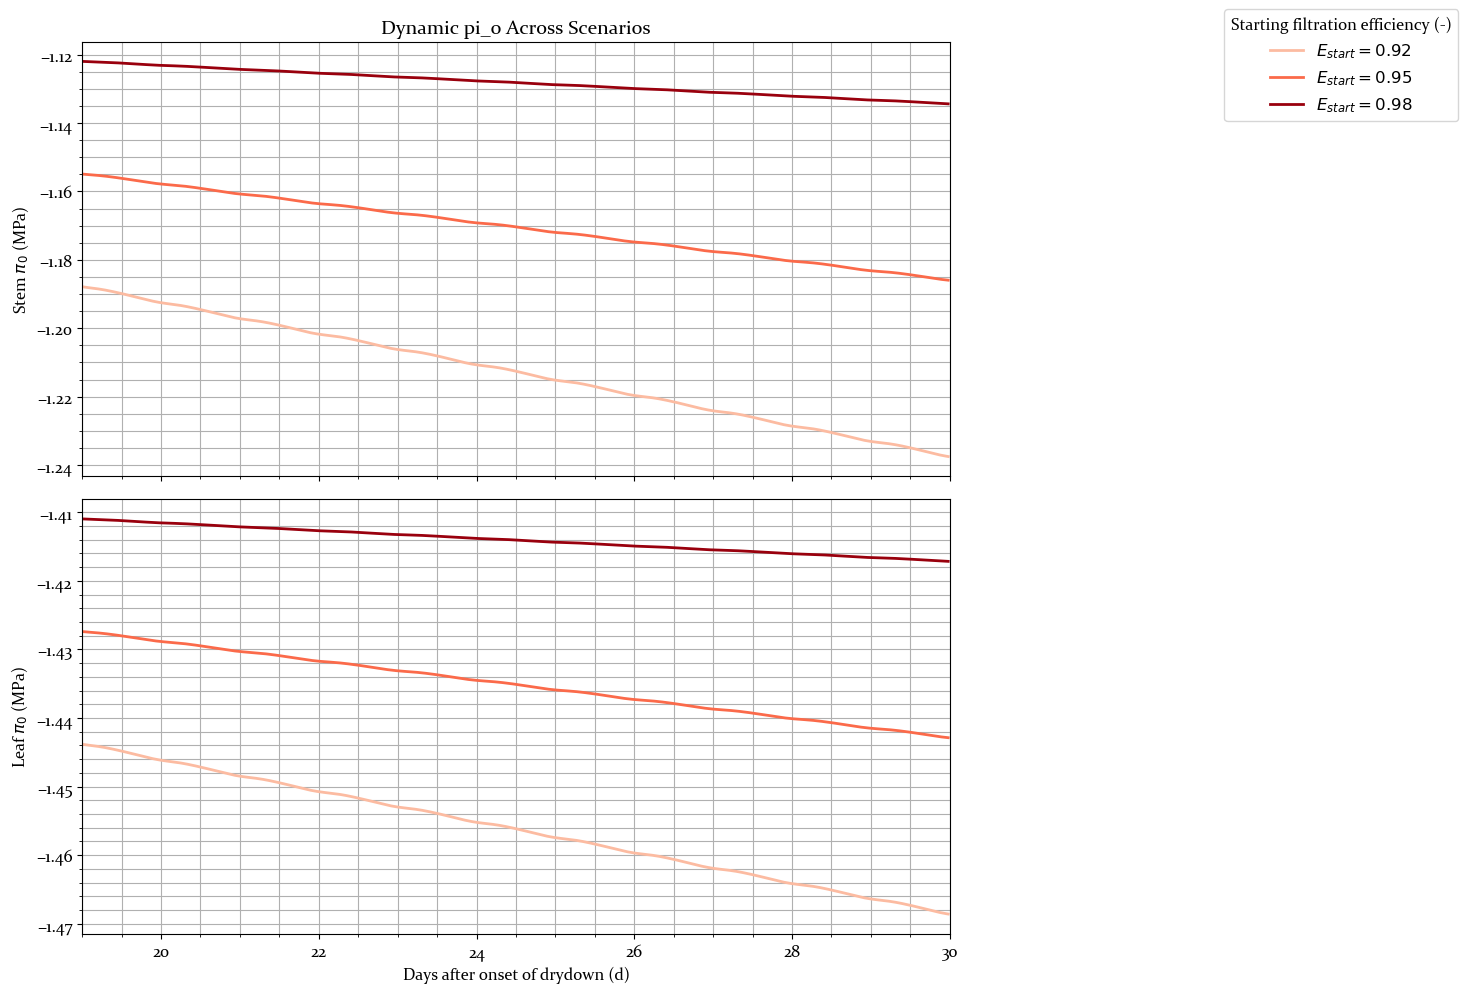

In [89]:
# Plot pi_0 timeseries for stem and leaf (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.extend([len(out["pi0_stem"]), len(out["pi0_leaf"])])

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax_stem_pi0, ax_leaf_pi0 = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    pi0_stem = np.array(out["pi0_stem"])[max_burn_in + plot_start_idx:n_plot]
    pi0_leaf = np.array(out["pi0_leaf"])[max_burn_in + plot_start_idx:n_plot]

    ax_stem_pi0.plot(time_plot, pi0_stem, linewidth=2, color=color, label=label)
    ax_leaf_pi0.plot(time_plot, pi0_leaf, linewidth=2, color=color, label=label)

ax_stem_pi0.set_title("Dynamic pi_0 Across Scenarios")
ax_stem_pi0.set_ylabel(r"Stem $\pi_0$ (MPa)")
ax_leaf_pi0.set_ylabel(r"Leaf $\pi_0$ (MPa)")
ax_leaf_pi0.set_xlabel("Days after onset of drydown (d)")

xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_stem_pi0.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "pi0_stem_leaf_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

In [90]:
# Diagnostics: verify c_leaf initialization and scenario divergence
for cfg in scenario_configs:
    name = cfg["name"]
    out = results_by_scenario[name]["output"]
    c_leaf_arr = np.array(out["c_leaf"])
    burn = int(results_by_scenario[name]["burn_in_steps"])
    print(f"{name}: c_leaf[0]={c_leaf_arr[0]:.6f}, c_leaf[burn]={c_leaf_arr[burn]:.6f}, c_leaf[-1]={c_leaf_arr[-1]:.6f}")

print("\nDelta from burn step to end:")
base = np.array(results_by_scenario["S1"]["output"]["c_leaf"])
for name in ["S2", "S3"]:
    arr = np.array(results_by_scenario[name]["output"]["c_leaf"])
    print(f"{name}-S1 at burn={arr[480]-base[480]:.6f}, end={arr[-1]-base[-1]:.6f}")

S1: c_leaf[0]=0.015765, c_leaf[burn]=0.014725, c_leaf[-1]=14.518747
S2: c_leaf[0]=0.015765, c_leaf[burn]=0.014725, c_leaf[-1]=9.080020
S3: c_leaf[0]=0.015765, c_leaf[burn]=0.014725, c_leaf[-1]=3.640993

Delta from burn step to end:
S2-S1 at burn=0.000000, end=-5.438726
S3-S1 at burn=0.000000, end=-10.877754


In [91]:
# Diagnostic: check diurnal variability of uptake driver terms (S3)
name = "S3"
out = results_by_scenario[name]["output"]

dt_s = dt
steps_per_day = int((24 * 60) / timestepM)

# Time series
c_stem_arr = np.array(out["c_stem"])
ev_arr = np.array(out["ev"])
qs_arr = np.array(out["qs"])  # can be (n_comp, n_t) or (n_t, n_comp)

# Positive inflow term used by uptake in HalophyteStemLeafStorageMultiComp
qs_pos = np.maximum(np.array(qs_arr), 0.0)
if qs_pos.shape[0] == len(cs_init_arr):
    qs_pos = qs_pos.T

cs_used = np.array(post_burn_cs_arr if enable_post_burn_cs_reset else cs_init_arr)
qcs = np.sum(qs_pos * cs_used, axis=1)

cfg_s3 = [c for c in scenario_configs if c["name"] == name][0]
E_init = float(cfg_s3.get("E", 0.99))
c_max = float(cfg_s3.get("c_stem_max", np.max(cs_used)))
c_thresh = E_init * c_max

E_dyn = np.where(
    c_stem_arr < c_thresh,
    E_init,
    np.minimum(E_init + (1 - E_init) * (c_stem_arr - c_thresh) / (c_max - c_thresh), 0.9999),
)

uptake_rate = qcs * (1 - E_dyn) * 1e-6  # mol m^-2 s^-1

# Hour-of-day averages over full simulation
hour_idx = (np.arange(len(ev_arr)) % steps_per_day) * timestepM / 60.0
hour_bins = np.arange(0, 24)

print("S3 diagnostics:")
print(f"  c_thresh = {c_thresh:.4f}, c_max = {c_max:.4f}")
print(f"  E range  = [{E_dyn.min():.6f}, {E_dyn.max():.6f}]")
print(f"  ev range = [{ev_arr.min():.6f}, {ev_arr.max():.6f}]")
print(f"  uptake rate range = [{uptake_rate.min():.6e}, {uptake_rate.max():.6e}] mol m^-2 s^-1")

print("\nHourly means (ev, qcs, uptake_rate):")
for h in hour_bins:
    mask = (hour_idx >= h) & (hour_idx < h + 1)
    print(
        f"  h={h:02d}: ev={ev_arr[mask].mean():.4f}, "
        f"qcs={qcs[mask].mean():.4f}, uptake={uptake_rate[mask].mean():.6e}"
    )

# Show whether c_stem growth increments are nearly constant
dc = np.diff(c_stem_arr)
print("\nDelta c_stem stats per step:")
print(f"  min={dc.min():.6e}, max={dc.max():.6e}, mean={dc.mean():.6e}, std={dc.std():.6e}")

S3 diagnostics:
  c_thresh = 147.0000, c_max = 150.0000
  E range  = [0.980000, 0.980000]
  ev range = [0.001244, 0.078187]
  uptake rate range = [0.000000e+00, 2.530302e-07] mol m^-2 s^-1

Hourly means (ev, qcs, uptake_rate):
  h=00: ev=0.0024, qcs=3.6991, uptake=7.398152e-08
  h=01: ev=0.0021, qcs=3.3125, uptake=6.625084e-08
  h=02: ev=0.0019, qcs=2.9590, uptake=5.917981e-08
  h=03: ev=0.0084, qcs=2.7724, uptake=5.544720e-08
  h=04: ev=0.0294, qcs=3.0636, uptake=6.127206e-08
  h=05: ev=0.0400, qcs=3.3944, uptake=6.788709e-08
  h=06: ev=0.0472, qcs=3.6720, uptake=7.344041e-08
  h=07: ev=0.0502, qcs=4.0485, uptake=8.096950e-08
  h=08: ev=0.0490, qcs=4.3779, uptake=8.755844e-08
  h=09: ev=0.0476, qcs=4.6480, uptake=9.296023e-08
  h=10: ev=0.0460, qcs=4.8742, uptake=9.748427e-08
  h=11: ev=0.0444, qcs=5.0606, uptake=1.012112e-07
  h=12: ev=0.0430, qcs=5.2083, uptake=1.041668e-07
  h=13: ev=0.0420, qcs=5.3156, uptake=1.063124e-07
  h=14: ev=0.0412, qcs=5.4036, uptake=1.080722e-07
  h=15: 

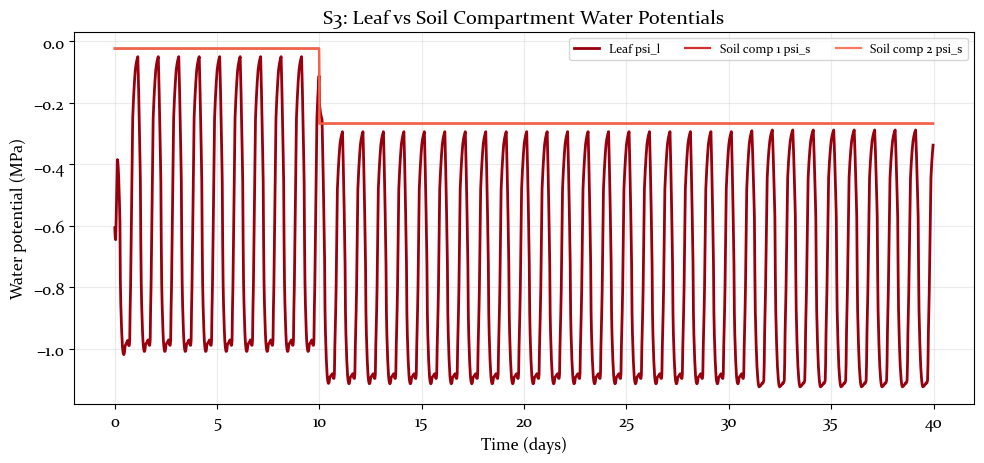

In [21]:
# Quick diagnostic: leaf water potential vs reconstructed soil compartment potentials
scenario_name = "S3"  # change if needed

diagnostic_palette = ["#99000d", "#cb181d", "#fb6a4a"]

out = results_by_scenario[scenario_name]["output"]
psi_l = np.array(out["psi_l"])
psi_b = np.array(out["psi_b"])

# gsr and qs are stored as [comp][time] in this notebook setup
gsr = np.array(out["gsr"])
qs = np.array(out["qs"])

if gsr.shape[0] != num_compartments:
    gsr = gsr.T
if qs.shape[0] != num_compartments:
    qs = qs.T

# From qs_i = gsr_i * (psi_s_i - psi_b)  =>  psi_s_i = psi_b + qs_i / gsr_i
psi_s_comp = psi_b[None, :] + qs / np.maximum(gsr, 1e-12)

time_days = np.arange(len(psi_l)) * timestepM / (60 * 24)

plt.figure(figsize=(10, 4.8))
plt.plot(time_days, psi_l, lw=2.0, color=diagnostic_palette[0], label="Leaf psi_l")
for i in range(num_compartments):
    plt.plot(time_days, psi_s_comp[i], lw=1.6, alpha=0.9, color=diagnostic_palette[min(i + 1, len(diagnostic_palette) - 1)], label=f"Soil comp {i+1} psi_s")

plt.xlabel("Time (days)")
plt.ylabel("Water potential (MPa)")
plt.title(f"{scenario_name}: Leaf vs Soil Compartment Water Potentials")
plt.grid(alpha=0.25)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

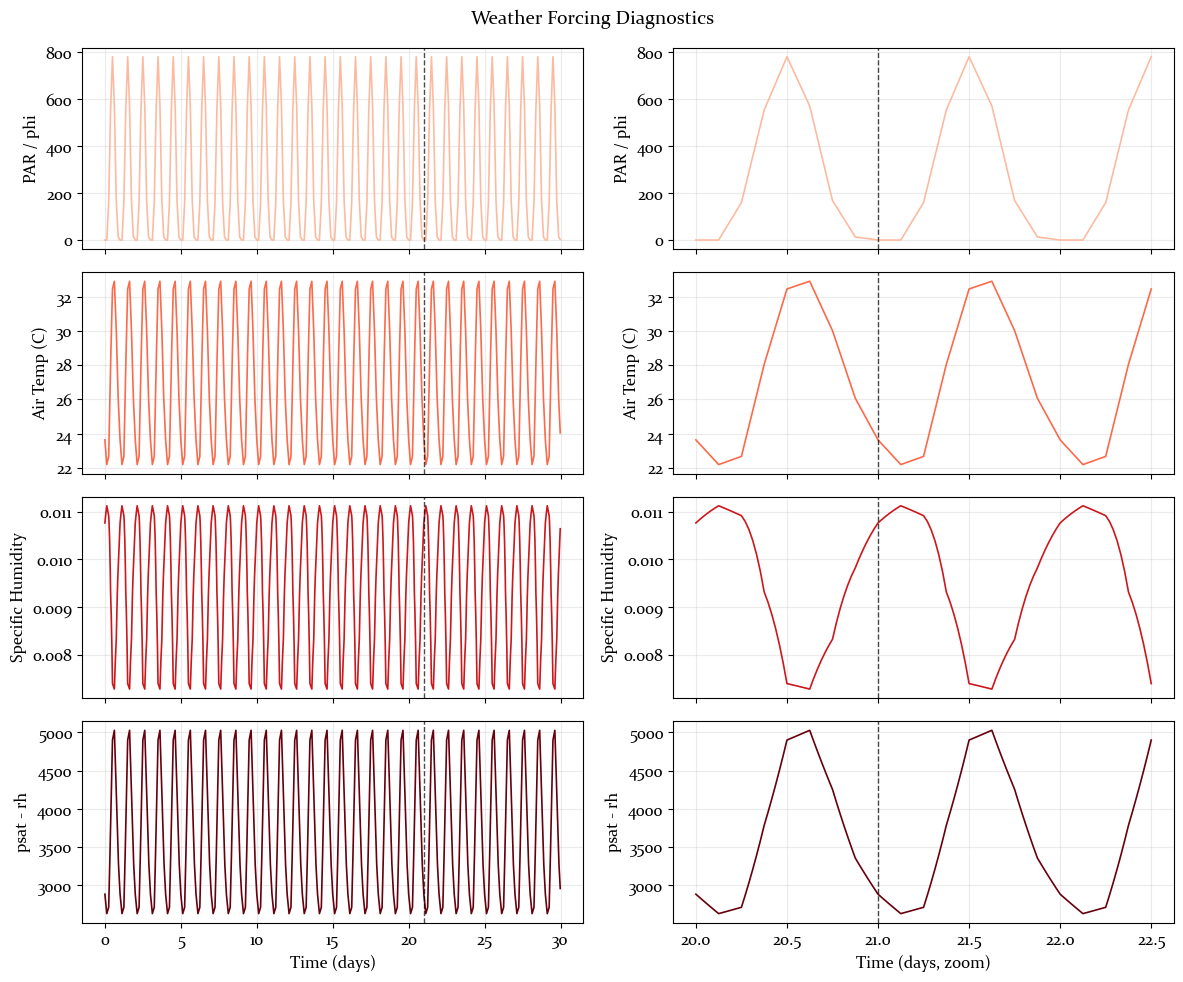

In [22]:
# Diagnostic weather plot (full run + zoom around day 21)
# Uses the weather forcing arrays actually fed to the simulation.

n_show = int(n_steps)
time_days_weather = np.arange(n_show) * timestepM / (60 * 24)

phi_arr = np.array(phiInp[:n_show], dtype=float)
ta_arr = np.array(taInp[:n_show], dtype=float)
qa_arr = np.array(qaInp[:n_show], dtype=float)

ta_c = ta_arr - 273.15  # convert K to C for readability
weather_palette = ["#fcbba1", "#fb6a4a", "#cb181d", "#67000d"]

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex='col')
fig.suptitle('Weather Forcing Diagnostics', fontsize=14)

# Full period
axes[0, 0].plot(time_days_weather, phi_arr, color=weather_palette[0], lw=1.2)
axes[0, 0].set_ylabel('PAR / phi')
axes[0, 0].grid(alpha=0.25)

axes[1, 0].plot(time_days_weather, ta_c, color=weather_palette[1], lw=1.2)
axes[1, 0].set_ylabel('Air Temp (C)')
axes[1, 0].grid(alpha=0.25)

axes[2, 0].plot(time_days_weather, qa_arr, color=weather_palette[2], lw=1.2)
axes[2, 0].set_ylabel('Specific Humidity')
axes[2, 0].grid(alpha=0.25)

vpd_like = np.maximum(0.0, np.array(psat[:n_show], dtype=float) - np.array(rh[:n_show], dtype=float))
axes[3, 0].plot(time_days_weather, vpd_like, color=weather_palette[3], lw=1.2)
axes[3, 0].set_ylabel('psat - rh')
axes[3, 0].set_xlabel('Time (days)')
axes[3, 0].grid(alpha=0.25)

for r in range(4):
    axes[r, 0].axvline(21, color='k', ls='--', lw=1, alpha=0.7)

# Zoom around day ~21
zoom_min, zoom_max = 20.0, 22.5
mask = (time_days_weather >= zoom_min) & (time_days_weather <= zoom_max)

axes[0, 1].plot(time_days_weather[mask], phi_arr[mask], color=weather_palette[0], lw=1.2)
axes[0, 1].set_ylabel('PAR / phi')
axes[0, 1].grid(alpha=0.25)

axes[1, 1].plot(time_days_weather[mask], ta_c[mask], color=weather_palette[1], lw=1.2)
axes[1, 1].set_ylabel('Air Temp (C)')
axes[1, 1].grid(alpha=0.25)

axes[2, 1].plot(time_days_weather[mask], qa_arr[mask], color=weather_palette[2], lw=1.2)
axes[2, 1].set_ylabel('Specific Humidity')
axes[2, 1].grid(alpha=0.25)

axes[3, 1].plot(time_days_weather[mask], vpd_like[mask], color=weather_palette[3], lw=1.2)
axes[3, 1].set_ylabel('psat - rh')
axes[3, 1].set_xlabel('Time (days, zoom)')
axes[3, 1].grid(alpha=0.25)

for r in range(4):
    axes[r, 1].axvline(21, color='k', ls='--', lw=1, alpha=0.7)

plt.tight_layout()
plt.show()